# Exploratory Data Analysis
Analysis of Brent Oil Prices including Trend, Stationarity, and Volatility.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import importlib

# Enable autoreload to pick up changes in src modules automatically
%load_ext autoreload
%autoreload 2

# Add src to path so we can import modules
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

import data_loader
importlib.reload(data_loader) # Force reload
from data_loader import load_data

from eda_utils import check_stationarity

# Set plot style
plt.style.use('seaborn-v0_8')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Load data used the extracted loader
file_path = '../data/BrentOilPrices.csv'
df = load_data(file_path)

print("Data Range:", df.index.min(), "to", df.index.max())
df.head()

Data Range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


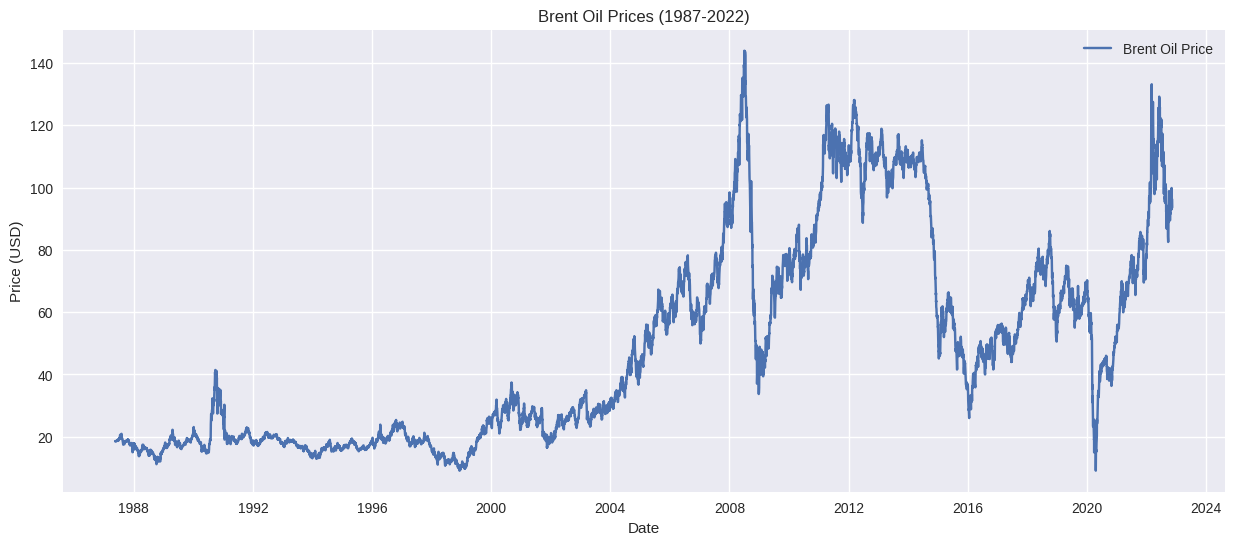

Linear Trend Slope: 0.00632 (Price change per day)


In [12]:
# Trend Analysis with Visualization
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Price'], label='Brent Oil Price')
plt.title('Brent Oil Prices (1987-2022)')
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.legend()
plt.show()

# Calculate linear trend
df['ordinal_date'] = df.index.map(pd.Timestamp.toordinal)
slope, intercept = np.polyfit(df['ordinal_date'], df['Price'], 1)
print(f"Linear Trend Slope: {slope:.5f} (Price change per day)")

--- ADF Test for Raw Prices ---
ADF Statistic: -1.993856
p-value: 0.289274
Result: Non-Stationary (Fail to reject H0)
--- ADF Test for First Difference ---
ADF Statistic: -1.993856
p-value: 0.289274
Result: Non-Stationary (Fail to reject H0)
--- ADF Test for First Difference ---
ADF Statistic: -15.529368
p-value: 0.000000
Result: Stationary (Reject H0)
ADF Statistic: -15.529368
p-value: 0.000000
Result: Stationary (Reject H0)


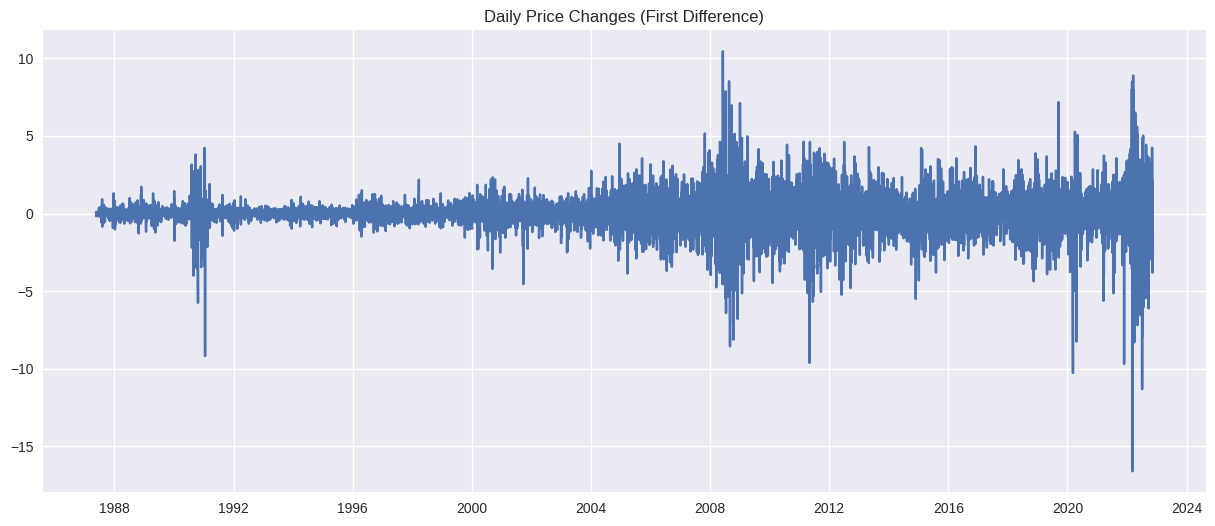

In [13]:
# Stationarity Test (ADF) using imported utility
check_stationarity(df['Price'], "Raw Prices")

# First Difference
df['diff_price'] = df['Price'].diff()
check_stationarity(df['diff_price'], "First Difference")

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['diff_price'])
plt.title('Daily Price Changes (First Difference)')
plt.show()

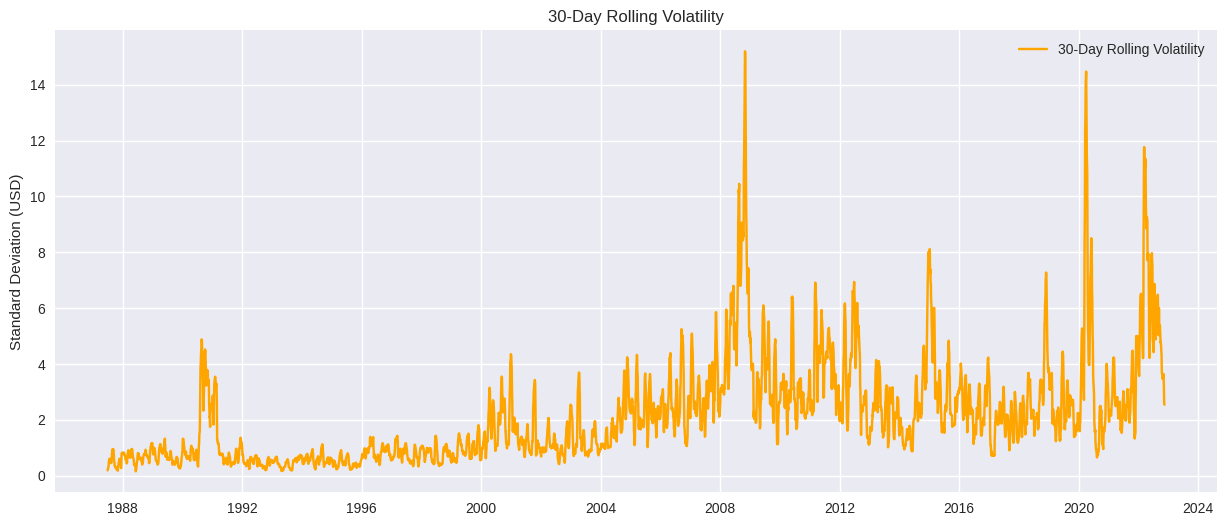

Average 30-day Volatility: 2.14
Max 30-day Volatility: 15.20


In [14]:
# Volatility Analysis (Rolling Standard Deviation)
window = 30
df['volatility_30d'] = df['Price'].rolling(window=window).std()

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['volatility_30d'], color='orange', label='30-Day Rolling Volatility')
plt.title('30-Day Rolling Volatility')
plt.ylabel('Standard Deviation (USD)')
plt.legend()
plt.show()

print(f"Average {window}-day Volatility: {df['volatility_30d'].mean():.2f}")
print(f"Max {window}-day Volatility: {df['volatility_30d'].max():.2f}")

# Conceptual Model Structure
Before building the full Bayesian model, we define the conceptual structure of the Change Point process.

The model assumes that the parameters of the time series (e.g., Mean Price $\mu$) changes abruptly at a specific point in time $\tau$.

1.  **Priors**:
    *   $\mu_1, \mu_2$: Average price before and after the change.
    *   $\sigma$: Volatility of the price (assumed constant or changing).
    *   $\tau$: The time step where the switch occurs (Uniform distribution over the timeline).

2.  **Likelihood**:
    *   Observed Prices $y$ follow a Normal distribution centered at $\mu_1$ (if $t < \tau$) or $\mu_2$ (if $t \ge \tau$).

```mermaid
graph TD
    subgraph Priors
    Tau[Change Point :: Tau]
    Mu1[Mean 1 :: Mu_1]
    Mu2[Mean 2 :: Mu_2]
    Sigma[Volatility :: Sigma]
    end
    
    Tau --> Decision{t < Tau?}
    Mu1 --> Decision
    Mu2 --> Decision
    
    Decision -->|Yes| CurrentMean[Current Mean = Mu_1]
    Decision -->|No| CurrentMean[Current Mean = Mu_2]
    
    CurrentMean --> Likelihood[Likelihood :: Normal Distribution]
    Sigma --> Likelihood
    
    Likelihood --> Observed[Observed Price Data]
    
    style Observed fill:#f9f,stroke:#333,stroke-width:2px
```

In [ ]:
# Visualizing the Change Point Concept
# This plot illustrates the assumed data generation process
np.random.seed(42)
t_steps = 100
tau_true = 60
mu1_true = 20
mu2_true = 40
sigma_true = 2

# Generate synthetic data
t = np.arange(t_steps)
mu = np.concatenate([np.repeat(mu1_true, tau_true), np.repeat(mu2_true, t_steps - tau_true)])
y = np.random.normal(mu, sigma_true)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, y, 'o', alpha=0.5, label='Observed Data')
plt.plot(t, mu, 'r-', linewidth=3, label='Latent Mean ($\mu$)')
plt.axvline(tau_true, color='k', linestyle='--', label=r'Change Point ($\tau$)')

# Annotations
plt.text(tau_true/2, mu1_true + 5, r'$\mu_1$', fontsize=15, color='red')
plt.text(tau_true + (t_steps-tau_true)/2, mu2_true - 5, r'$\mu_2$', fontsize=15, color='red')

plt.title('Conceptual Change Point Model')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()